In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# 5 Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

Matplotlib is building the font cache; this may take a moment.


In [2]:
# 2. Load and Prepare Data
print("Loading Data...")
df = pd.read_csv("../data/processed/resumes_cleaned.csv").dropna()

X_text = df['cleaned_text']
y_label = df['label']

# Encode Labels (Ubah teks kategori menjadi angka 0, 1, 2... untuk XGBoost)
encoder = LabelEncoder()
y = encoder.fit_transform(y_label)

print(f"Total data: {len(df)} resumes")
print(f"Total categories: {len(encoder.classes_)}")

Loading Data...
Total data: 2483 resumes
Total categories: 24


In [3]:
# 3. Feature Engineering & Data Splitting
print("Membuat TF-IDF Features...")
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X_text)

# Split data: 80% untuk Training, 20% untuk Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")

Membuat TF-IDF Features...
Ukuran X_train: (1986, 5000)
Ukuran X_test: (497, 5000)


In [4]:
# 4. Setup 5 Model Machine Learning
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "SVM (LinearSVC)": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

results = []

In [5]:
# 5. Training dan Evaluasi Semua Model
print("Mulai proses training untuk 5 model...")

for model_name, model in models.items():
    print(f"\n⏳ Training {model_name}...")
    start_time = time.time()
    
    # Latih model
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Prediksi data test
    y_pred = model.predict(X_test)
    
    # Hitung akurasi
    accuracy = accuracy_score(y_test, y_pred)
    print(f"✅ Selesai ({train_time:.2f} detik) | Akurasi: {accuracy*100:.2f}%")
    
    results.append({
        "Model": model_name,
        "Accuracy (%)": round(accuracy * 100, 2),
        "Training Time (s)": round(train_time, 2)
    })

df_results = pd.DataFrame(results)
display(df_results.sort_values(by="Accuracy (%)", ascending=False))

Mulai proses training untuk 5 model...

⏳ Training Logistic Regression...
✅ Selesai (1.18 detik) | Akurasi: 65.59%

⏳ Training Naive Bayes...
✅ Selesai (0.01 detik) | Akurasi: 54.53%

⏳ Training SVM (LinearSVC)...
✅ Selesai (0.71 detik) | Akurasi: 71.43%

⏳ Training Random Forest...
✅ Selesai (5.96 detik) | Akurasi: 68.81%

⏳ Training XGBoost...


d:\Project\01 Skills\AI-Resume-Screener\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [15:28:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Selesai (134.02 detik) | Akurasi: 77.87%


,Model,Accuracy (%),Training Time (s)
4,XGBoost,77.87,134.02
2,SVM (LinearSVC),71.43,0.71
3,Random Forest,68.81,5.96
0,Logistic Regression,65.59,1.18
1,Naive Bayes,54.53,0.01


C:\Users\Willy Hanafi\AppData\Local\Temp\ipykernel_18508\790762380.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy (%)", y="Model", data=df_results.sort_values(by="Accuracy (%)", ascending=False), palette="viridis")


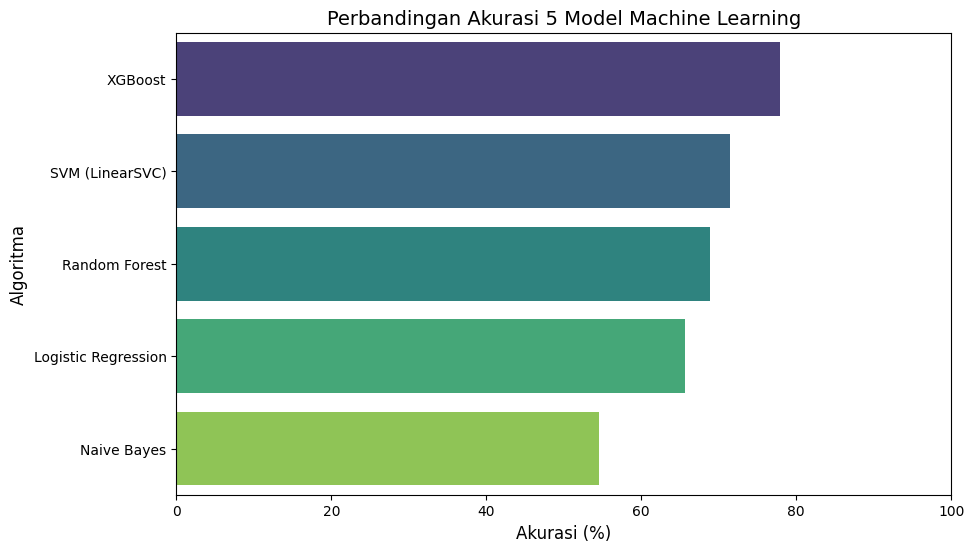

In [6]:
# 6. Visualisasi Perbandingan Model
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy (%)", y="Model", data=df_results.sort_values(by="Accuracy (%)", ascending=False), palette="viridis")
plt.title("Perbandingan Akurasi 5 Model Machine Learning", fontsize=14)
plt.xlabel("Akurasi (%)", fontsize=12)
plt.ylabel("Algoritma", fontsize=12)
plt.xlim(0, 100)
plt.show()